In [1]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

In [2]:

# Load processed dataset
fraud_df = pd.read_csv("../data/processed/fraud_feature_engineered.csv")

# Load trained model
best_rf_fraud = joblib.load(
    "../models/fraud_random_forest.pkl"
)

In [3]:
type(best_rf_fraud)

sklearn.ensemble._forest.RandomForestClassifier

In [4]:

fraud_df.columns.tolist()

['user_id',
 'purchase_value',
 'device_id',
 'age',
 'ip_address',
 'class',
 'time_since_signup',
 'hour_of_day',
 'day_of_week',
 'user_transaction_count',
 'device_transaction_count',
 'lower_bound_ip_address',
 'upper_bound_ip_address',
 'source_Direct',
 'source_SEO',
 'browser_FireFox',
 'browser_IE',
 'browser_Opera',
 'browser_Safari',
 'sex_M',
 'country_Albania',
 'country_Algeria',
 'country_Angola',
 'country_Antigua and Barbuda',
 'country_Argentina',
 'country_Armenia',
 'country_Australia',
 'country_Austria',
 'country_Azerbaijan',
 'country_Bahamas',
 'country_Bahrain',
 'country_Bangladesh',
 'country_Barbados',
 'country_Belarus',
 'country_Belgium',
 'country_Belize',
 'country_Benin',
 'country_Bermuda',
 'country_Bhutan',
 'country_Bolivia',
 'country_Bonaire; Sint Eustatius; Saba',
 'country_Bosnia and Herzegowina',
 'country_Botswana',
 'country_Brazil',
 'country_British Indian Ocean Territory',
 'country_Brunei Darussalam',
 'country_Bulgaria',
 'country_Burk

In [5]:
X_fraud = fraud_df.drop("class", axis=1)
y_fraud = fraud_df["class"]

print(X_fraud.shape)
print(y_fraud.shape)

(129146, 199)
(129146,)


In [6]:
X_fraud = X_fraud.drop("device_id", axis=1)

In [7]:
X_fraud.select_dtypes(include="object").columns

Index([], dtype='object')

In [8]:
from sklearn.model_selection import train_test_split

X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

In [9]:
print(len(X_train_fraud.columns))
print(best_rf_fraud.n_features_in_)

198
198


In [10]:
import pandas as pd

importances = pd.DataFrame({
    "Feature": X_train_fraud.columns,
    "Importance": best_rf_fraud.feature_importances_
})

importances = importances.sort_values(
    by="Importance",
    ascending=False
)

top10 = importances.head(10)

top10

,Feature,Importance
8,device_transaction_count,0.233310
4,time_since_signup,0.221190
3,ip_address,0.050989
0,user_id,0.048055
9,lower_bound_ip_address,0.047536
10,upper_bound_ip_address,0.047408
1,purchase_value,0.043316
5,hour_of_day,0.042060
2,age,0.039669
6,day_of_week,0.032741


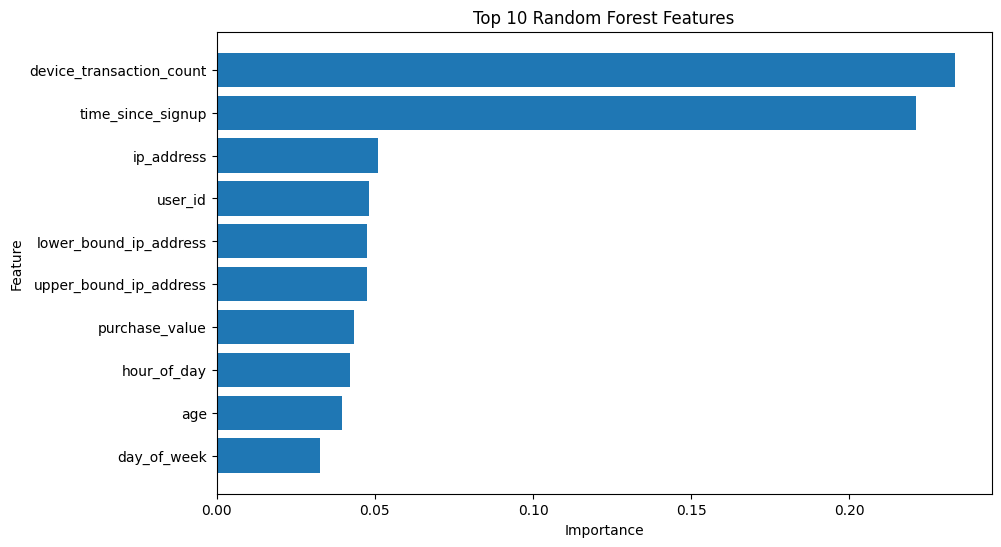

In [11]:
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")

plt.gca().invert_yaxis()

plt.show()

SHAP

In [12]:
type(best_rf_fraud)

sklearn.ensemble._forest.RandomForestClassifier

In [13]:
import joblib

best_rf_fraud = joblib.load(
    "../models/fraud_random_forest.pkl"
)

In [14]:
X_test_fraud.shape

(25830, 198)

In [17]:
import shap

X_sample = shap.sample(
    X_test_fraud,
    200,
    random_state=42
)import shap

X_sample = shap.sample(
    X_test_fraud,
    200,
    random_state=42
)

In [18]:
X_sample.shape

(200, 198)

In [19]:
import shap

print(shap.__version__)

0.49.1


In [21]:
X_train_fraud.select_dtypes(include="object").columns

Index([], dtype='object')

In [24]:
X_sample.select_dtypes(include="object").columns

Index([], dtype='object')

In [25]:
X_sample.dtypes.value_counts()

bool       187
int64        8
float64      3
Name: count, dtype: int64

In [27]:
X_sample.dtypes.value_counts()

bool       187
int64        8
float64      3
Name: count, dtype: int64

In [28]:
X_sample.isnull().sum().sum()

np.int64(0)

In [29]:
(X_sample.dtypes == "bool").sum()

np.int64(187)

In [30]:
X_sample_numeric = X_sample.astype(float)

In [33]:
X_sample_numeric.dtypes.value_counts()

float64    198
Name: count, dtype: int64

In [35]:
type(best_rf_fraud)
X_sample.shape
X_sample.dtypes.value_counts()
X_sample.isnull().sum().sum()
(X_sample.dtypes == "bool").sum()

np.int64(187)

In [36]:
type(best_rf_fraud)

sklearn.ensemble._forest.RandomForestClassifier

In [38]:
hasattr(best_rf_fraud, "estimators_")

True

In [39]:
len(best_rf_fraud.feature_importances_)

198

In [40]:
X_sample_numeric.shape[1]

198

In [41]:
best_rf_fraud.predict(
    X_sample_numeric.iloc[:5]
)

array([0, 0, 0, 0, 0])

In [ ]:
import shap

X_small = X_sample_numeric.sample(
    n=20,
    random_state=42
)

explainer = shap.TreeExplainer(best_rf_fraud)

shap_values = explainer.shap_values(
    X_small,
    check_additivity=False
)

In [ ]:
print(type(shap_values))

In [34]:
explainer = shap.Explainer(
    best_rf_fraud,
    X_sample
)

Found a NULL input array in _cext_dense_tree_update_weights!


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [26]:
explainer = shap.Explainer(
    best_rf_fraud,
    X_sample
)

Found a NULL input array in _cext_dense_tree_update_weights!


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [ ]:
import shap

X_sample = shap.sample(
    X_test_fraud,
    200,
    random_state=42
)

In [ ]:
print(X_test_fraud.shape)
print(type(X_test_fraud))

In [ ]:
X_small = shap.sample(X_test_fraud, 200, random_state=42).values

In [ ]:
import shap

# 1. Take a small sample from your test set (recommended for speed)
small_sample = shap.sample(X_test_fraud, 200, random_state=42)

# 2. Initialize SHAP explainer
explainer = shap.TreeExplainer(best_rf_fraud)

# 3. Compute SHAP values
shap_values = explainer.shap_values(
    small_sample,
    approximate=True,
    check_additivity=False
)

In [ ]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)
print(X_test_fraud.shape)

In [ ]:
print(shap_values[1].shape)
print(small_sample.shape)

In [ ]:
explainer = shap.TreeExplainer(
    best_rf_fraud
)

shap_values = explainer.shap_values(
    X_test_fraud
)